## 5005A1 Bonus - Propose an improvement to XGBOOST training strategy

Propose and test an improvement. For bonus marks, identify a specific limitation or potential enhancement to the original algorithm, this could involve a different preprocessing step, an architectural tweak, a new loss function, or an **alternative training strategy**.
Implement this improvement, run a comparative experiment against your baseline reimplementation, and report whether it leads to measurable gains, providing a clear justification for why the change was expected to help.




In [1]:
import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------------------
# Environment Setup
# ---------------------------------------------------------------------------
# mount google drive, DIrectory for data and output files : /5005/A1
# Use the local dataset directory.
data_dir = Path("/content/drive/MyDrive/5005/A1")

# ---------------------------------------------------------------------------
# 0) Configuration & Reproducibility Setup
# ---------------------------------------------------------------------------
# Define the file path for saving the final joined dataset.
out_file = data_dir / "mimic_iv_ed_v22_joined.csv"

# Set a global random state seed to ensure consistent, reproducible results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ==========================================
# Loading Data Files
# ==========================================
print("Loading data and creating aggregate data sets...")

# 1. Load core ED stays and triage tables
ed_stays = pd.read_csv(os.path.join(data_dir, "ed_stays.csv"))
triage = pd.read_csv(os.path.join(data_dir, "triage.csv"))
print("ed_stays"); display(ed_stays.head())
print("triage"); display(triage.head())

# Load patient demographics restricting to specific columns to optimize memory.
demo_cols = ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
patients = pd.read_csv(os.path.join(data_dir, 'patient_demographics.csv'), usecols=demo_cols)
print("patients"); display(patients.head())


# 2. Load and Aggregate One-to-Many Tables
# Vitals: Assume continuous monitoring, take the mean per stay_id
vitals = pd.read_csv(os.path.join(data_dir, "vitals.csv"))
vitals_agg = vitals.groupby('stay_id').mean(numeric_only=True).add_prefix('mean_')
print("vitals"); display(vitals.head(), vitals_agg.head())
# skipped rythm and pain as they are not numeric, *** explore ways to readd

# ED Diagnosis: Count total diagnoses per stay
ed_diagnosis = pd.read_csv(os.path.join(data_dir, "ed_diagnosis.csv"))
diag_agg = ed_diagnosis.groupby('stay_id').size().reset_index(name='total_diagnoses')
print("ed_diagnosis"); display(ed_diagnosis.head())
print("diag_agg"); display(diag_agg.head())

# Medrecon: Create binary flags if the patient had records in these tables
medrecon = pd.read_csv(os.path.join(data_dir, "medrecon.csv"))
medrecon_agg = medrecon[['stay_id']].drop_duplicates()
medrecon_agg['has_medrecon'] = 1
print("medrecon_agg"); display(medrecon.head(), medrecon_agg.head())

# Same for Pyxis: Create binary flags if the patient had records in these tables
pyxis = pd.read_csv(os.path.join(data_dir, "pyxis.csv"))
pyxis_agg = pyxis[['stay_id']].drop_duplicates()
pyxis_agg['has_pyxis_meds'] = 1
print("pyxis"); display(pyxis.head(), pyxis_agg.head())


Mounted at /content/drive
Loading data and creating aggregate data sets...
ed_stays


,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,6/05/2180 19:17,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,26/06/2180 15:54,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,5/08/2180 20:58,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,22/07/2180 16:24,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,23/07/2180 5:54,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED


triage


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention"
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain"
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC"


patients


...

,subject_id,stay_id,charttime,name,gsn,ndc,etc_rn,etccode,etcdescription
0,10000032,32952584,22/07/2180 17:26,albuterol sulfate,28090,21695042308,1,5970.0,Asthma/COPD Therapy - Beta 2-Adrenergic Agents...
1,10000032,32952584,22/07/2180 17:26,calcium carbonate,1340,10135021101,1,733.0,Minerals and Electrolytes - Calcium Replacement
2,10000032,32952584,22/07/2180 17:26,cholecalciferol (vitamin D3),65241,37205024678,1,670.0,Vitamins - D Derivatives
3,10000032,32952584,22/07/2180 17:26,emtricitabine-tenofovir [Truvada],57883,35356007003,1,5849.0,Antiretroviral - Nucleoside and Nucleotide Ana...
4,10000032,32952584,22/07/2180 17:26,fluticasone [Flovent HFA],21251,49999061401,1,371.0,Asthma Therapy - Inhaled Corticosteroids (Gluc...


,stay_id,has_medrecon
0,32952584,1
14,33258284,1
24,35968195,1
31,38112554,1
44,39399961,1


pyxis


,subject_id,stay_id,charttime,med_rn,name,gsn_rn,gsn
0,10000032,32952584,22/07/2180 17:59,1,Albuterol Inhaler,1,5037.0
1,10000032,32952584,22/07/2180 17:59,1,Albuterol Inhaler,2,28090.0
2,10000032,35968195,5/08/2180 22:29,1,Morphine,1,4080.0
3,10000032,35968195,5/08/2180 22:55,2,Donnatol (Elixir),1,4773.0
4,10000032,35968195,5/08/2180 22:55,3,Aluminum-Magnesium Hydrox.-Simet,1,2701.0


,stay_id,has_pyxis_meds
0,32952584,1
2,35968195,1
8,38112554,1
11,39399961,1
25,35203156,1


In [2]:
####################################
# 3. Merge Everything Together
####################################
print("Merging tables...")

# Base merge: stays + demographics
df = ed_stays.merge(patients, on='subject_id', how='left')
display(df.head())


# Compute approximate age at time of ED visit: Age = anchor_age + (visit_year - anchor_year)
# Example, When a patient's visit year matches their anchor year, the temporal difference in your formula becomes zero:
df['intime'] = pd.to_datetime(df['intime'], dayfirst=True)

df['age'] = df['anchor_age'] + (df['intime'].dt.year - df['anchor_year'])

pd.set_option('display.max_rows', 100)
display(df.head(20))

# Merge with triage and aggregated tables
df = df.merge(triage, on='stay_id', how='left')
df = df.merge(vitals_agg, on='stay_id', how='left')
df = df.merge(diag_agg, on='stay_id', how='left')
df = df.merge(medrecon_agg, on='stay_id', how='left')
df = df.merge(pyxis_agg, on='stay_id', how='left')

# Fill missing values for the new aggregated flags
df['total_diagnoses'] = df['total_diagnoses'].fillna(0)
df['has_medrecon'] = df['has_medrecon'].fillna(0)
df['has_pyxis_meds'] = df['has_pyxis_meds'].fillna(0)

# 4. Create Targets
# Binary Target: Hospital Admission
df['admission'] = df['hadm_id'].notna().astype(int)

# Multiclass Target: Disposition Ward (careunit)
ward_mapping = {'ADMITTED': 'General', 'TRANSFER': 'General',
        'OBSERVATION': 'Observational',
        'CARDIOLOGY': 'Cardiology',
        'ICU': 'ICU',
        'SURGICAL': 'Surgical',
        'NEUROLOGY': 'Neurology',
        'OBSTETRICS': 'Obstetrics',
        'ONCOLOGY': 'Oncology'}

def map_ward(disposition):
  if pd.isna(disposition):
    return 'General'
  disp_str = str(disposition).upper()
  for key, val in ward_mapping.items():
    if key in disp_str:
      return val
      return 'General'

df['careunit'] = df['disposition'].apply(map_ward)

pd.set_option('display.max_rows', 50)
display(df.head(10))
# df.to_csv(data_dir / "mimic_iv_ed_processed.csv", index=False)

raw_df = df # Assign to raw_df as used in previous cell
pd.set_option('display.max_columns', None)
display(raw_df.head(10))

Merging tables...


,subject_id,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,22595853.0,33258284,6/05/2180 19:17,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
1,10000032,22841357.0,38112554,26/06/2180 15:54,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
2,10000032,25742920.0,35968195,5/08/2180 20:58,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180
3,10000032,29079034.0,32952584,22/07/2180 16:24,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180
4,10000032,29079034.0,39399961,23/07/2180 5:54,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180


,subject_id,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,...,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,...,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,...,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,...,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,...,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,...,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,...,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,...,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,...,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,...,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,...,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None


In [3]:
# encode chiefcomplaint free text field into a categorised new field called PRESENTING_PROB
import re

# 1. Define regex patterns for categorizing chief complaints
presenting_problem_patterns = [
    ("Abdominal pain", re.compile(r"\b(?:abd|abdominal|rlq|llq|ruq|luq|epigastric)\b|\bflank pain\b")),
    ("Chest pain", re.compile(r"\b(?:chest pain|cp)\b")),
    ("Respiratory", re.compile(r"\b(?:dyspnea|sob|shortness of breath|cough|asthma|wheez|hypoxia|respiratory|ili)\b")),
    ("Trauma or injury", re.compile(r"\b(?:s/p fall|fall|mvc|assault|trauma|injury|fracture|laceration|head injury|burn)\b")),
    ("Neurological", re.compile(r"\b(?:headache|seizure|altered mental status|ams|confusion|stroke|cva|neuro)\b")),
    ("Dizziness or syncope", re.compile(r"\b(?:dizziness|syncope|near syncope|weakness|lightheaded)\b")),
    ("Mental health or substance use", re.compile(r"\b(?:si|suicidal|depression|anxiety|psych|etoh|alcohol|overdose|substance|detox)\b")),
    ("Infection or fever", re.compile(r"\b(?:fever|infection|sepsis|chills)\b")),
    ("Gastrointestinal symptoms", re.compile(r"\b(?:n/v|nausea|vomiting|diarrhea|brbpr|gi bleed|rectal bleeding|constipation)\b")),
    ("Genitourinary", re.compile(r"\b(?:dysuria|hematuria|urinary|retention|kidney|renal|testicular)\b")),
    ("Obstetric or gynecological", re.compile(r"\b(?:vaginal|pregnan|pelvic|ob|gyn)\b")),
    ("Cardiovascular", re.compile(r"\b(?:palpitations|hypertension|hypotension|tachycardia|bradycardia)\b")),
    ("Skin or wound", re.compile(r"\b(?:wound|rash|cellulitis|abscess|skin)\b")),
    ("ENT, eye, or dental", re.compile(r"\b(?:sore throat|eye|vision|ear|dental|tooth|nose|epistaxis)\b")),
    ("Abnormal labs or tests", re.compile(r"\b(?:abnormal labs|lab|hyperglycemia|hypoglycemia)\b")),
    ("Transfer or administrative", re.compile(r"\b(?:transfer|med refill|medical clearance)\b")),
]

# 2. Define the categorization function
def categorise_presenting_problem(chiefcomplaint):
    """Categorizes the primary chief complaint into a standardized bucket."""
    if pd.isna(chiefcomplaint):
        return "Unknown"

    # Extract the first complaint if multiple are listed (separated by commas)
    first_problem = str(chiefcomplaint).split(",", 1)[0].strip().lower()

    if first_problem in {"", "___", "nan", "none"}:
        return "Unknown"

    # Match against the defined regex patterns
    for category, pattern in presenting_problem_patterns:
        if pattern.search(first_problem):
            return category

    return "Other"

# 3. Apply the categorization directly to the main dataframe (df)
# The 'chiefcomplaint' column was brought over when df.merge(triage) was executed previously.
df["PRESENTING_PROB"] = df["chiefcomplaint"].apply(categorise_presenting_problem)

# 4. Display the results
display(df[["chiefcomplaint", "PRESENTING_PROB"]].head(10))
display(df["PRESENTING_PROB"].value_counts(dropna=False))
display(df.head(10))
df.to_csv("5005A1-merged-dataset.csv", index=False)

,chiefcomplaint,PRESENTING_PROB
0,"Abd pain, Abdominal distention",Abdominal pain
1,Abdominal distention,Abdominal pain
2,"n/v/d, Abd pain",Gastrointestinal symptoms
3,Hypotension,Cardiovascular
4,"Abdominal distention, Abd pain, LETHAGIC",Abdominal pain
5,"Confusion, Hallucinations",Neurological
6,"Altered mental status, B Pedal edema",Neurological
7,"LEFT CHEEK SWELLING, Abscess",Other
8,L CHEEK ABSCESS,Skin or wound
9,L FACIAL SWELLING,Other


,count
PRESENTING_PROB,
Other,127973
Abdominal pain,52721
Trauma or injury,39903
Respiratory,28709
Chest pain,27723
Mental health or substance use,25082
Neurological,22551
Dizziness or syncope,19427
Gastrointestinal symptoms,17802


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit,PRESENTING_PROB
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General,Abdominal pain
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General,Abdominal pain
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General,Gastrointestinal symptoms
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None,Cardiovascular
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General,Abdominal pain
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General,Neurological
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None,Neurological
7,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None,Other
8,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None,Skin or wound
9,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None,Other


In [4]:
# Perform EDA on categorical variables with counts and percentages

#!pip install -U ipykernel

categorical_columns = ['gender_x', 'gender_y', 'race', 'arrival_transport', 'admission', 'PRESENTING_PROB']

for column in categorical_columns:
    category_counts = df[column].value_counts(dropna=False)
    category_summary = pd.DataFrame({
        'count': category_counts,
        'percentage': (category_counts / len(df) * 100).round(1),
    })

    category_summary['percentage'] = category_summary['percentage'].map('{:.1f}%'.format)

    print(f'\n{column}')

    display(category_summary)


gender_x


,count,percentage
gender_x,,
F,229898,54.1%
M,195189,45.9%



gender_y


,count,percentage
gender_y,,
F,229912,54.1%
M,195175,45.9%



race


...

,count,percentage
arrival_transport,,
WALK IN,251849,59.2%
AMBULANCE,155752,36.6%
UNKNOWN,15352,3.6%
OTHER,1266,0.3%
HELICOPTER,868,0.2%



admission


,count,percentage
admission,,
0,222071,52.2%
1,203016,47.8%



PRESENTING_PROB


,count,percentage
PRESENTING_PROB,,
Other,127973,30.1%
Abdominal pain,52721,12.4%
Trauma or injury,39903,9.4%
Respiratory,28709,6.8%
Chest pain,27723,6.5%
Mental health or substance use,25082,5.9%
Neurological,22551,5.3%
Dizziness or syncope,19427,4.6%
Gastrointestinal symptoms,17802,4.2%


In [5]:
# Filter for admitted stays (hadm_id is not null)
admitted_stays = raw_df[raw_df['hadm_id'].notna()]

# Calculate counts and percentages
disposition_stats = admitted_stays['disposition'].value_counts().to_frame(name='Count')
disposition_stats['Percentage'] = (disposition_stats['Count'] / len(admitted_stays) * 100).round(2).astype(str) + '%'

print("Statistics of admitted stays per disposition type:")
display(disposition_stats)

Statistics of admitted stays per disposition type:


,Count,Percentage
disposition,,
ADMITTED,157626,77.64%
HOME,36497,17.98%
TRANSFER,4696,2.31%
OTHER,2548,1.26%
ELOPED,1182,0.58%
LEFT AGAINST MEDICAL ADVICE,343,0.17%
LEFT WITHOUT BEING SEEN,110,0.05%
EXPIRED,14,0.01%


# Rationale for 18% of admissions resulting home disposition
The 18% (17.98%) of records where a patient has a hospital admission ID (hadm_id) but an emergency department (ED) disposition of HOME is due to few structural and clinical reasons:

**Data Linking of Return Visits**: In the MIMIC-IV database architecture, an ED visit is often linked to a hospital admission if the timelines are very close. If a patient visits the ED, is discharged HOME, but returns hours later and is officially admitted, the database linkage algorithms frequently append the new hadm_id to the prior ED stay record.

**Observation Status**: Patients are frequently placed in an ED observation unit for extended monitoring (e.g., 12 to 24 hours). This observation status often triggers the creation of a formal hadm_id for hospital billing and administrative tracking. If the patient recovers during this window, their final physical disposition is HOME without ever transferring to an inpatient ward.

**Change in Clinical Plan**: An ED physician may decide to admit a patient, triggering the administrative system to generate a hadm_id and request an inpatient bed. If the patient's condition rapidly improves while waiting in the ED, the clinical team may cancel the inpatient transfer and discharge them HOME instead.

**Clerical Discrepancies**: A staff member might mistakenly log the preliminary disposition as HOME in the ED system, or fail to update the ED record after a later decision is made to admit the patient to a hospital ward.

For the purpose of this study we are considering the presence of a hadm_id value as the decision to admit the patient even if it did not result an ***actual admission***.

In [6]:
# ==========================================
# STEP 2: Feature Engineering (Integrated)
# ==========================================
print("Engineering features...")

# Sort chronologically per patient for historical features
raw_df = raw_df.sort_values(by=['subject_id_x', 'intime']).reset_index(drop=True)

raw_df['nth_stay'] = raw_df.groupby('subject_id_x').cumcount() + 1
raw_df['admissions_before'] = raw_df.groupby('subject_id_x')['admission'].cumsum() - raw_df['admission']

raw_df['admission_ratio'] = np.where(
    raw_df['nth_stay'] > 1,
    raw_df['admissions_before'] / (raw_df['nth_stay'] - 1),
    0.0
)

raw_df['month'] = raw_df['intime'].dt.strftime('%B')
raw_df['weekday'] = raw_df['intime'].dt.strftime('%A')

def time_to_slot(hour):
    if 0 <= hour < 4: return '0-4'
    elif 4 <= hour < 8: return '4-8'
    elif 8 <= hour < 12: return '8-12'
    elif 12 <= hour < 16: return '12-16'
    elif 16 <= hour < 20: return '16-20'
    else: return '20-24'

raw_df['time_slot'] = raw_df['intime'].dt.hour.apply(time_to_slot)
raw_df['pain_clean'] = pd.to_numeric(raw_df['pain'], errors='coerce')

df_engineered = raw_df # Assign to df_engineered for the next step

# Updated feature arrays to include the new aggregated columns
NUMERICAL_COLS = [
    'age', 'temperature', 'heartrate', 'resprate', 'sbp', 'dbp',
    'admission_ratio', 'admissions_before', 'nth_stay',
    'total_diagnoses', 'has_medrecon', 'has_pyxis_meds'
]
ORDINAL_COLS = ['acuity', 'pain_clean']
NOMINAL_COLS = ['arrival_transport', 'gender', 'month', 'weekday', 'time_slot']

display(raw_df.head(10))
# Export dataset
# raw_df.to_csv(data_dir / "raw_df_mimic_iv_ed_processed.csv", index=False)

Engineering features...


,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit,PRESENTING_PROB,nth_stay,admissions_before,admission_ratio,month,weekday,time_slot,pain_clean
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General,Abdominal pain,1,0,0.0,May,Saturday,16-20,0.0
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.90,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General,Abdominal pain,2,1,1.0,June,Monday,12-16,10.0
2,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.80,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None,Cardiovascular,3,2,1.0,July,Saturday,16-20,7.0
3,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.70,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General,Abdominal pain,4,3,1.0,July,Sunday,4-8,13.0
4,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.40,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General,Gastrointestinal symptoms,5,4,1.0,August,Saturday,20-24,10.0
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General,Neurological,1,0,0.0,November,Thursday,20-24,0.0
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.70,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None,Neurological,2,1,1.0,December,Saturday,16-20,0.0
7,10000108,NaN,32522732,2163-09-16 16:34:00,16/09/2163 18:13,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,L CHEEK ABSCESS,10000108.0,98.200000,66.000000,15.000000,100.000000,111.000000,62.000000,1.0,0.0,0.0,0,None,Skin or wound,1,0,0.0,September,Friday,16-20,5.0
8,10000108,NaN,39513268,2163-09-24 16:14:00,24/09/2163 21:02,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,101.0,18.0,100.0,131.0,62.0,5,3.0,L FACIAL SWELLING,10000108.0,98.400000,64.000000,18.000000,98.000000,109.000000,69.000000,1.0,0.0,1.0,0,None,Other,2,0,0.0,September,Saturday,16-20,5.0
9,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.80,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None,Other,3,0,0.0,September,Tuesday,16-20,5.0


In [7]:
# ==========================================
# STEP 3: Outlier Removal & Preprocessing (Integrated)
# ==========================================
print("Preprocessing data and handling outliers...")

mask = pd.Series(True, index=df_engineered.index)
for col in NUMERICAL_COLS:
    if col in df_engineered.columns:
        Q1 = df_engineered[col].quantile(0.25)
        Q3 = df_engineered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        mask = mask & ((df_engineered[col].isna()) | ((df_engineered[col] >= lower_bound) & (df_engineered[col] <= upper_bound)))

df_clean = df_engineered[mask].copy()

# Ensure columns exist before processing
existing_num_cols = [c for c in NUMERICAL_COLS if c in df_clean.columns]
existing_ord_cols = [c for c in ORDINAL_COLS if c in df_clean.columns]
existing_cat_cols = [c for c in NOMINAL_COLS if c in df_clean.columns]

# 1. Numerical
num_imputer = SimpleImputer(strategy='mean')
scaler = MinMaxScaler()
X_num = num_imputer.fit_transform(df_clean[existing_num_cols])
X_num_scaled = scaler.fit_transform(X_num)
df_num_processed = pd.DataFrame(X_num_scaled, columns=existing_num_cols, index=df_clean.index)

# 2. Ordinal
ord_imputer = SimpleImputer(strategy='most_frequent')
X_ord = ord_imputer.fit_transform(df_clean[existing_ord_cols])
df_ord_processed = pd.DataFrame(X_ord, columns=existing_ord_cols, index=df_clean.index)

# 3. Nominal
cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat_imp = cat_imputer.fit_transform(df_clean[existing_cat_cols])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_ohe = ohe.fit_transform(X_cat_imp)
ohe_cols = ohe.get_feature_names_out(existing_cat_cols)
df_cat_processed = pd.DataFrame(X_cat_ohe, columns=ohe_cols, index=df_clean.index)

X = pd.concat([df_num_processed, df_ord_processed, df_cat_processed], axis=1)
y_admission = df_clean['admission']
y_careunit = df_clean['careunit']

# Export engineered dataset X - rerun if making changes above to refresh the Bonus notebvook
# output_path_X = data_dir / "X_features_processed.csv"
# X.to_csv(output_path_X, index=False)


Preprocessing data and handling outliers...


In [13]:
# ==========================================
# STEP 4: Model Training and Evaluation (Integrated)
# ==========================================
print("\n==========================================")
print("TASK 1: Binary Hospital Admission Prediction")
print("==========================================")

X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

xgb_adm = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_adm.fit(X_train_adm, y_train_adm)
print(f"[XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, xgb_adm.predict(X_test_adm)):.4f}")
print(f"[XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, xgb_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

ada_adm = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_adm.fit(X_train_adm, y_train_adm)
print(f"[AdaBoost] Admission Accuracy: {accuracy_score(y_test_adm, ada_adm.predict(X_test_adm)):.4f}")
print(f"[AdaBoost] Admission AUROC:    {roc_auc_score(y_test_adm, ada_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

print("\n==========================================")
print("TASK 2: Multiclass Disposition Ward Prediction")
print("==========================================")

admitted_idx = y_admission[y_admission == 1].index
X_res = X.loc[admitted_idx]
y_res = y_careunit.loc[admitted_idx]

unique_careunits = y_res.nunique()
print(f"Unique values in y_res for admitted patients: {y_res.value_counts()}")

if unique_careunits < 2:
    print("Skipping multiclass classification: Not enough unique careunit classes for admitted patients.")
else:
    labels, y_res_encoded = np.unique(y_res, return_inverse=True)

    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_res_encoded
    )

    xgb_res = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE)
    xgb_res.fit(X_train_res, y_train_res)
    print(f"[XGBoost] Resource Macro F1: {f1_score(y_test_res, xgb_res.predict(X_test_res), average='macro'):.4f}")
    print(f"[XGBoost] Resource AUROC:    {roc_auc_score(y_test_res, xgb_res.predict_proba(X_test_res), multi_class='ovr'):.4f}")


TASK 1: Binary Hospital Admission Prediction
[XGBoost] Admission Accuracy: 0.7625
[XGBoost] Admission AUROC:    0.8436
[AdaBoost] Admission Accuracy: 0.7442
[AdaBoost] Admission AUROC:    0.8219

TASK 2: Multiclass Disposition Ward Prediction
Unique values in y_res for admitted patients: careunit
General    135591
Name: count, dtype: int64
Skipping multiclass classification: Not enough unique careunit classes for admitted patients.


In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
# Assuming X_train_adm and y_train_adm are already defined from your train_test_split

# 1. Define your model (using XGBoost from your existing imports)
model = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')

# 2. Define the hyperparameter grid you want to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 3. Configure Repeated 10-Fold Cross-Validation
# n_splits=10 for 10-fold, n_repeats is typically set to 3 or 5 for repeated CV
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

# 4. Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc', # You can change this to 'accuracy' or 'f1' based on your needs
    n_jobs=-1,         # Uses all available CPU cores for faster computation
    verbose=1          # Shows progress output
)

# 5. Execute the search on the training data
print("Starting Grid Search...")
grid_result = grid_search.fit(X_train_adm, y_train_adm)

# 6. Output the best results
print(f"Best ROC-AUC Score: {grid_result.best_score_:.4f}")
print(f"Best Parameters: {grid_result.best_params_}")

# To use the best model for predictions later:
best_model = grid_result.best_estimator_

Starting Grid Search...
Fitting 30 folds for each of 27 candidates, totalling 810 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [14:20:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best ROC-AUC Score: 0.8441
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


### Saving and Loading the Optimized Model

To persist the `best_xgb_model` across Colab sessions, we can save it to a file using `joblib` and then load it when needed. This avoids the need to re-run the potentially time-consuming Grid Search every time the session restarts.

### Loading the Saved Model (in a new session)

In a fresh Colab session, after mounting your drive and defining `data_dir`, you can load the model like this:

### Using Grid Search Results to Optimize the Model

Now that the Grid Search has identified the best hyperparameters, we can use these to initialize a new XGBoost model. This optimized model will then be trained on the training data and evaluated on the test data to assess its performance with the tuned parameters.

In [14]:
#########################################################
# Rerun the training with the optimized model parameters
#########################################################
import joblib

# Assuming 'data_dir' is already defined from your setup cells
model_load_path = data_dir / 'best_xgb_admission_model.joblib'

# Load the model
loaded_model = joblib.load(model_load_path)
print(f"Optimized XGBoost model loaded from: {model_load_path}")

# You can now use 'loaded_model' for predictions or further analysis
# For example, to make predictions with the loaded model:
y_pred_loaded = loaded_model.predict(X_test_adm)
print(f"Loaded Model Accuracy: {accuracy_score(y_test_adm, y_pred_loaded):.4f}")

# ==========================================
# STEP 4 Optimized: Model Training and Evaluation (Integrated)
# ==========================================
print("\n==========================================")
print("TASK 1b: Optimized Binary Hospital Admission Prediction")
print("==========================================")

X_train_adm, X_test_adm, y_train_adm, y_test_adm = train_test_split(
    X, y_admission, test_size=0.30, random_state=RANDOM_STATE, stratify=y_admission
)

# modify as per the gridsearch results
xgb_adm = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=7, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_adm.fit(X_train_adm, y_train_adm)
print(f"[XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, xgb_adm.predict(X_test_adm)):.4f}")
print(f"[XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, xgb_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

# Adaboost increase estimators to 200
ada_adm = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada_adm.fit(X_train_adm, y_train_adm)
print(f"[AdaBoost] Admission Accuracy: {accuracy_score(y_test_adm, ada_adm.predict(X_test_adm)):.4f}")
print(f"[AdaBoost] Admission AUROC:    {roc_auc_score(y_test_adm, ada_adm.predict_proba(X_test_adm)[:, 1]):.4f}")

print("\n==========================================")
print("TASK 2: Multiclass Disposition Ward Prediction")
print("==========================================")

admitted_idx = y_admission[y_admission == 1].index
X_res = X.loc[admitted_idx]
y_res = y_careunit.loc[admitted_idx]

unique_careunits = y_res.nunique()
print(f"Unique values in y_res for admitted patients: {y_res.value_counts()}")

if unique_careunits < 2:
    print("Skipping multiclass classification: Not enough unique careunit classes for admitted patients.")
else:
    labels, y_res_encoded = np.unique(y_res, return_inverse=True)

    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_res_encoded
    )

    xgb_res = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=RANDOM_STATE)
    xgb_res.fit(X_train_res, y_train_res)
    print(f"[XGBoost] Resource Macro F1: {f1_score(y_test_res, xgb_res.predict(X_test_res), average='macro'):.4f}")
    print(f"[XGBoost] Resource AUROC:    {roc_auc_score(y_test_res, xgb_res.predict_proba(X_test_res), multi_class='ovr'):.4f}")

Optimized XGBoost model loaded from: /content/drive/MyDrive/5005/A1/best_xgb_admission_model.joblib
Loaded Model Accuracy: 0.7628

TASK 1b: Optimized Binary Hospital Admission Prediction
[XGBoost] Admission Accuracy: 0.7628
[XGBoost] Admission AUROC:    0.8439
[AdaBoost] Admission Accuracy: 0.7471
[AdaBoost] Admission AUROC:    0.8254

TASK 2: Multiclass Disposition Ward Prediction
Unique values in y_res for admitted patients: careunit
General    135591
Name: count, dtype: int64
Skipping multiclass classification: Not enough unique careunit classes for admitted patients.


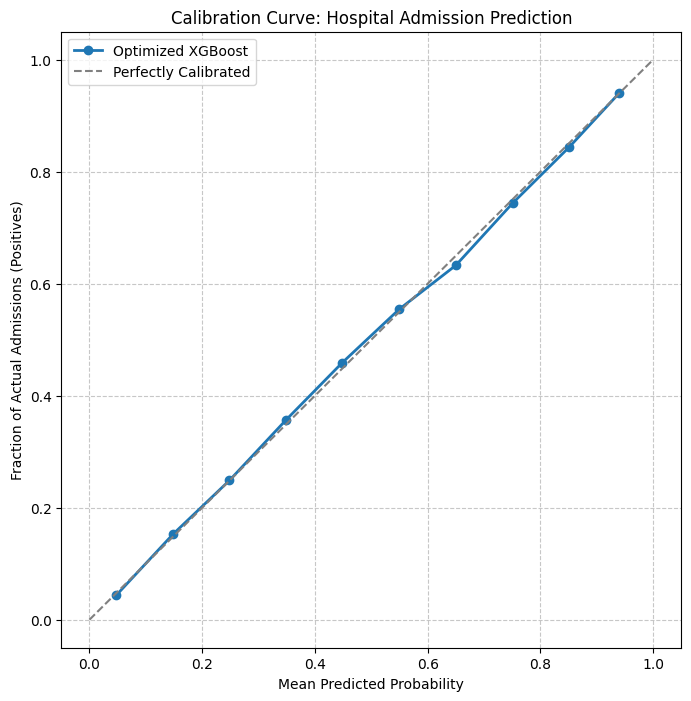

In [16]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# 1. Get predicted probabilities for the positive class (Admission)
y_pred_proba = xgb_adm.predict_proba(X_test_adm)[:, 1]

# 2. Compute the true fraction of positives and the mean predicted probabilities per bin
prob_true, prob_pred = calibration_curve(y_test_adm, y_pred_proba, n_bins=10)

# 3. Plot the calibration curve (Reliability Diagram)
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Optimized XGBoost')

# Add the diagonal reference line for a perfectly calibrated model
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Formatting
plt.title('Calibration Curve: Hospital Admission Prediction')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Admissions (Positives)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
# ==========================================
# STEP 4c: Patient-Aware Chronological Split (Latest Admission as Test)
# ==========================================
print("\n==========================================")
print("TASK 4c: Binary Admission (Latest Admission Test Set)")
print("==========================================")

# 1. Isolate all admitted records
# Using 'hadm_id' to filter, or you can use y_admission == 1
admitted_mask = raw_df['hadm_id'].notna()
admissions_df = raw_df[admitted_mask].copy()

display(admissions_df.head(10))

# 2. Sort by patient ID and ED arrival time to ensure chronological order
# (If your arrival time column is named differently than 'intime', update it below)
admissions_df = admissions_df.sort_values(by=['subject_id', 'intime'])

# 3. Extract the indices of the *last* admission for each patient
test_idx = admissions_df.groupby('subject_id').tail(1).index

# 4. Everything else goes into the training set
train_idx = raw_df.index.difference(test_idx)

# 5. Split the feature matrix (X) and target (y_admission) using these indices
X_train_adm = X.loc[train_idx]
y_train_adm = y_admission.loc[train_idx]
X_test_adm = X.loc[test_idx]
y_test_adm = y_admission.loc[test_idx]

print(f"Training set size: {len(X_train_adm)} stays")
print(f"Testing set size:  {len(X_test_adm)} stays (latest admissions only)")

# 6. Train the Optimized XGBoost model on this new temporal split
optimized_xgb_adm_4c = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    eval_metric='logloss',
    random_state=42
)

optimized_xgb_adm_4c.fit(X_train_adm, y_train_adm)

# 7. Generate predictions and evaluate
y_pred_4c = optimized_xgb_adm_4c.predict(X_test_adm)
y_pred_proba_4c = optimized_xgb_adm_4c.predict_proba(X_test_adm)[:, 1]

print(f"\n[Patient-Split XGBoost] Admission Accuracy: {accuracy_score(y_test_adm, y_pred_4c):.4f}")
print(f"[Patient-Split XGBoost] Admission AUROC:    {roc_auc_score(y_test_adm, y_pred_proba_4c):.4f}")

,subject_id_x,hadm_id,stay_id,intime,outtime,gender_x,race,arrival_transport,disposition,gender_y,anchor_age,anchor_year,anchor_year_group,dod,age,subject_id_y,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,mean_subject_id,mean_temperature,mean_heartrate,mean_resprate,mean_o2sat,mean_sbp,mean_dbp,total_diagnoses,has_medrecon,has_pyxis_meds,admission,careunit,PRESENTING_PROB,nth_stay,admissions_before,admission_ratio,month,weekday,time_slot,pain_clean
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,6/05/2180 23:30,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",10000032.0,97.700000,79.000000,16.000000,98.000000,107.000000,60.000000,4.0,1.0,0.0,1,General,Abdominal pain,1,0,0.0,May,Saturday,16-20,0.0
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,26/06/2180 21:31,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,10000032.0,97.900000,81.000000,17.500000,94.000000,95.500000,60.500000,4.0,1.0,1.0,1,General,Abdominal pain,2,1,1.0,June,Monday,12-16,10.0
2,10000032,29079034.0,32952584,2180-07-22 16:24:00,23/07/2180 5:54,F,WHITE,AMBULANCE,HOME,F,52,2180,2014 - 2016,9/09/2180,52,10000032,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,10000032.0,98.300000,84.571429,20.285714,98.000000,79.428571,42.857143,3.0,1.0,1.0,1,None,Cardiovascular,3,2,1.0,July,Saturday,16-20,7.0
3,10000032,29079034.0,39399961,2180-07-23 05:54:00,23/07/2180 14:00,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",10000032.0,98.550000,85.727273,16.909091,94.363636,84.181818,50.545455,2.0,1.0,1.0,1,General,Abdominal pain,4,3,1.0,July,Sunday,4-8,13.0
4,10000032,25742920.0,35968195,2180-08-05 20:58:00,6/08/2180 1:44,F,WHITE,AMBULANCE,ADMITTED,F,52,2180,2014 - 2016,9/09/2180,52,10000032,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",10000032.0,98.300000,93.500000,17.500000,99.500000,100.000000,59.000000,3.0,1.0,1.0,1,General,Gastrointestinal symptoms,5,4,1.0,August,Saturday,20-24,10.0
5,10000084,23052089.0,35203156,2160-11-20 20:36:00,21/11/2160 3:20,M,WHITE,WALK IN,ADMITTED,M,72,2160,2017 - 2019,13/02/2161,72,10000084,97.5,78.0,16.0,100.0,114.0,71.0,0,2.0,"Confusion, Hallucinations",10000084.0,97.833333,71.000000,16.666667,97.000000,118.000000,73.666667,2.0,1.0,1.0,1,General,Neurological,1,0,0.0,November,Thursday,20-24,0.0
6,10000084,29888819.0,36954971,2160-12-27 18:32:00,28/12/2160 16:07,M,WHITE,AMBULANCE,HOME,M,72,2160,2017 - 2019,13/02/2161,72,10000084,98.7,80.0,16.0,95.0,111.0,72.0,0,2.0,"Altered mental status, B Pedal edema",10000084.0,98.300000,76.125000,16.750000,98.625000,117.000000,73.250000,2.0,1.0,1.0,1,None,Neurological,2,1,1.0,December,Saturday,16-20,0.0
9,10000108,27250926.0,36533795,2163-09-27 16:18:00,28/09/2163 9:04,M,WHITE,WALK IN,HOME,M,25,2163,2014 - 2016,NaN,25,10000108,98.8,98.0,16.0,100.0,135.0,85.0,5,3.0,"LEFT CHEEK SWELLING, Abscess",10000108.0,98.500000,69.800000,18.000000,99.600000,112.400000,72.200000,1.0,1.0,1.0,1,None,Other,3,0,0.0,September,Tuesday,16-20,5.0
12,10000117,22927623.0,32642808,2181-11-14 21:51:00,15/11/2181 2:06,F,WHITE,WALK IN,ADMITTED,F,48,2174,2008 - 2010,NaN,55,10000117,97.6,81.0,16.0,100.0,148.0,83.0,0,3.0,Throat foreign body sensation,10000117.0,98.225000,80.400000,18.600000,99.200000,140.400000,79.800000,1.0,1.0,0.0,1,General,Other,1,0,0.0,November,Wednesday,20-24,0.0
14,10000117,27988844.0,33176849,2183-09-18 08:41:00,18/09/2183 20:20,F,WHITE,WALK IN,ADMITTED,F,48,2174,2008 - 2010,NaN,57,10000117,97.5,104.0,16.0,99.0,130.0,71.0,7,4.0,L Hip pain,10000117.0,98.000000,95.666667,17.333333,97.666667,121.333333,72.666667,2.0,0.0,0.0,1,General,Other,3,1,0.5,September,Thursday,8-12,7.0
